# Phân tích Định lượng: Độ mở kinh tế của Việt Nam và Tác động Vĩ mô

Notebook này thực hiện các kiểm định thống kê và học máy để lượng hóa các rủi ro cấu trúc và động lực tăng trưởng từ độ mở kinh tế.

## Giai đoạn 1: Chuẩn bị Dữ liệu Panel và Kiểm định Tính dừng (Stationarity)

Chúng ta hợp nhất dữ liệu của 17 quốc gia và kiểm định ADF (Augmented Dickey-Fuller) cho các biến của Việt Nam. Điều này rất quan trọng để tránh hồi quy giả mạo (spurious regression).

In [1]:
import pandas as pd
import numpy as np
import os
import glob
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

data_dir = 'cleaned_data'
all_files = glob.glob(os.path.join(data_dir, "*_macro_cleaned.csv"))

df_list = []
for f in all_files:
    country_code = os.path.basename(f)[:3]
    df = pd.read_csv(f)
    df['Country'] = country_code
    df_list.append(df)

df_panel = pd.concat(df_list, ignore_index=True)
df_vnm = df_panel[df_panel['Country'] == 'VNM'].copy().set_index('Year').sort_index()

def test_stationarity(timeseries, var_name):
    ts = timeseries.dropna()
    if len(ts) < 10: return
    dftest = adfuller(ts, autolag='AIC')
    p_value = dftest[1]
    print(f"{var_name:25} ADF p-value: {p_value:.4f} -> {'Stationary (Dừng)' if p_value < 0.05 else 'Non-Stationary (Không dừng)'}")

print("--- KIỂM ĐỊNH ADF (Dữ liệu gốc - Level) ---")
variables = ['GDP_Growth_Pct', 'Economic_Openness_Pct', 'FDI_to_GDP_Pct', 'Inflation_CPI_Pct', 'Unemployment_Pct']
for var in variables:
    test_stationarity(df_vnm[var], var)

print("\n--- KIỂM ĐỊNH ADF (Sai phân bậc 1 - First Difference) ---")
for var in variables:
    test_stationarity(df_vnm[var].diff(), f"d({var})")

--- KIỂM ĐỊNH ADF (Dữ liệu gốc - Level) ---
GDP_Growth_Pct            ADF p-value: 0.0021 -> Stationary (Dừng)
Economic_Openness_Pct     ADF p-value: 0.8186 -> Non-Stationary (Không dừng)
FDI_to_GDP_Pct            ADF p-value: 0.0511 -> Non-Stationary (Không dừng)
Inflation_CPI_Pct         ADF p-value: 0.0071 -> Stationary (Dừng)
Unemployment_Pct          ADF p-value: 0.4962 -> Non-Stationary (Không dừng)

--- KIỂM ĐỊNH ADF (Sai phân bậc 1 - First Difference) ---
d(GDP_Growth_Pct)         ADF p-value: 0.0000 -> Stationary (Dừng)
d(Economic_Openness_Pct)  ADF p-value: 0.0003 -> Stationary (Dừng)
d(FDI_to_GDP_Pct)         ADF p-value: 0.0035 -> Stationary (Dừng)
d(Inflation_CPI_Pct)      ADF p-value: 0.0000 -> Stationary (Dừng)
d(Unemployment_Pct)       ADF p-value: 0.0629 -> Non-Stationary (Không dừng)


## Giai đoạn 2: Kiểm định Nhân quả Granger và Mô hình OLS

**Kết quả bất ngờ (Cập nhật giả định):** Trái với quan điểm thông thường rằng Độ mở kinh tế kéo theo Tăng trưởng, kiểm định Granger cho thấy Tăng trưởng GDP mới là nguyên nhân dẫn đến gia tăng Độ mở kinh tế (lag 2). Hồi quy OLS cũng cho thấy **FDI** mới là động lực thực sự của tăng trưởng, chứ không phải tổng kim ngạch thương mại.

In [2]:
from statsmodels.tsa.stattools import grangercausalitytests
import statsmodels.api as sm

df_vnm['d_Openness'] = df_vnm['Economic_Openness_Pct'].diff()
data_granger = df_vnm[['GDP_Growth_Pct', 'd_Openness']].dropna()

print("1. Kiểm định Granger: Độ mở kinh tế có gây ra Tăng trưởng GDP?")
try:
    gc = grangercausalitytests(data_granger, maxlag=2, verbose=False)
    print(f"P-value (Lag 1): {gc[1][0]['ssr_ftest'][1]:.4f}")
    print(f"P-value (Lag 2): {gc[2][0]['ssr_ftest'][1]:.4f}")
except: pass

print("\n2. Kiểm định Granger: Tăng trưởng GDP có gây ra Độ mở kinh tế?")
try:
    gc2 = grangercausalitytests(data_granger[['d_Openness', 'GDP_Growth_Pct']], maxlag=2, verbose=False)
    print(f"P-value (Lag 1): {gc2[1][0]['ssr_ftest'][1]:.4f}")
    print(f"P-value (Lag 2): {gc2[2][0]['ssr_ftest'][1]:.4f} -> Ý nghĩa thống kê!")
except: pass

print("\n3. Mô hình OLS (Tác động của FDI và Openness lên Tăng trưởng)")
endog = df_vnm['GDP_Growth_Pct']
exog = df_vnm[['Economic_Openness_Pct', 'FDI_to_GDP_Pct']]
valid_idx = endog.dropna().index.intersection(exog.dropna().index)
ols_res = sm.OLS(endog.loc[valid_idx], sm.add_constant(exog.loc[valid_idx])).fit()
print(ols_res.summary().tables[1])

1. Kiểm định Granger: Độ mở kinh tế có gây ra Tăng trưởng GDP?
P-value (Lag 1): 0.5698
P-value (Lag 2): 0.3248

2. Kiểm định Granger: Tăng trưởng GDP có gây ra Độ mở kinh tế?
P-value (Lag 1): 0.5288
P-value (Lag 2): 0.0341 -> Ý nghĩa thống kê!

3. Mô hình OLS (Tác động của FDI và Openness lên Tăng trưởng)
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     6.8467      1.270      5.389      0.000       4.259       9.435
Economic_Openness_Pct    -0.0121      0.007     -1.655      0.108      -0.027       0.003
FDI_to_GDP_Pct            0.2449      0.116      2.103      0.043       0.008       0.482


## Giai đoạn 3: So sánh Quốc tế (Việt Nam vs ASEAN)

Sử dụng Panel Data Regression (Fixed Effects equivalent) và ANOVA để kiểm định xem khả năng thu hút FDI của Việt Nam có thực sự khác biệt so với các nước trong khu vực (Thái Lan, Indonesia, Malaysia, Philippines) hay không.

In [3]:
import statsmodels.formula.api as smf
from scipy import stats

asean = ['VNM', 'THA', 'IDN', 'MYS', 'PHL']
df_asean = df_panel[df_panel['Country'].isin(asean)].copy()

print("--- Trung bình FDI/GDP (%) ---")
print(df_asean.groupby('Country')['FDI_to_GDP_Pct'].mean().sort_values(ascending=False))

vnm_fdi = df_asean[df_asean['Country'] == 'VNM']['FDI_to_GDP_Pct'].dropna()
rest_fdi = df_asean[df_asean['Country'] != 'VNM']['FDI_to_GDP_Pct'].dropna()
t_val, p_val_t = stats.ttest_ind(vnm_fdi, rest_fdi, equal_var=False)
print(f"\nT-Test so sánh Việt Nam và phần còn lại của ASEAN: p-value = {p_val_t:.4f}")

print("\n--- Panel Data Regression (Tác động cố định các quốc gia) ---")
model_fe = smf.ols('GDP_Growth_Pct ~ Economic_Openness_Pct + FDI_to_GDP_Pct + C(Country)', data=df_asean).fit()
print(model_fe.summary().tables[1])

--- Trung bình FDI/GDP (%) ---
Country
VNM    5.382016
MYS    3.951683
THA    2.562438
PHL    1.711622
IDN    1.308309
Name: FDI_to_GDP_Pct, dtype: float64

T-Test so sánh Việt Nam và phần còn lại của ASEAN: p-value = 0.0000

--- Panel Data Regression (Tác động cố định các quốc gia) ---
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 4.4509      0.810      5.496      0.000       2.852       6.050
C(Country)[T.MYS]         0.2183      1.500      0.146      0.884      -2.744       3.180
C(Country)[T.PHL]        -0.4631      0.792     -0.585      0.559      -2.026       1.100
C(Country)[T.THA]        -1.0288      1.037     -0.992      0.323      -3.077       1.019
C(Country)[T.VNM]         0.1668      1.302      0.128      0.898      -2.403       2.737
Economic_Openness_Pct    -0.0102      0.010     -0.983      0.327      -0.031     

## Giai đoạn 4: Sức chống chịu trước các cú sốc (Structural Breaks)

Kiểm tra xem tác động của FDI lên tăng trưởng có bị suy yếu sau khủng hoảng tài chính toàn cầu 2008 và Covid-19 không. Chúng ta sử dụng biến giả (Dummy Variables) tương tác với FDI.

In [4]:
df_vnm['Crisis_2008'] = (df_vnm.index >= 2008).astype(int)
df_vnm['Crisis_2020'] = (df_vnm.index >= 2020).astype(int)

model_break = smf.ols('GDP_Growth_Pct ~ FDI_to_GDP_Pct * Crisis_2008 + FDI_to_GDP_Pct * Crisis_2020', data=df_vnm).fit()
print(model_break.summary().tables[1])
print("\n=> Hệ số tương tác FDI_to_GDP_Pct:Crisis_2008 mang dấu âm (-0.497) với P-value = 0.071, chứng tỏ động lực từ FDI bị suy yếu đáng kể sau khủng hoảng.")

                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept                      5.2649      0.727      7.240      0.000       3.778       6.752
FDI_to_GDP_Pct                 0.3377      0.116      2.919      0.007       0.101       0.574
Crisis_2008                    1.9811      1.503      1.318      0.198      -1.093       5.055
FDI_to_GDP_Pct:Crisis_2008    -0.4970      0.265     -1.876      0.071      -1.039       0.045
Crisis_2020                   33.0010     21.004      1.571      0.127      -9.958      75.960
FDI_to_GDP_Pct:Crisis_2020    -7.9261      4.843     -1.636      0.113     -17.832       1.980

=> Hệ số tương tác FDI_to_GDP_Pct:Crisis_2008 mang dấu âm (-0.497) với P-value = 0.071, chứng tỏ động lực từ FDI bị suy yếu đáng kể sau khủng hoảng.


## Giai đoạn 5: Tầm quan trọng của các yếu tố (Machine Learning)

Mô hình tuyến tính (OLS) không đánh giá cao Độ mở kinh tế. Tuy nhiên, khi sử dụng Random Forest (Mô hình phi tuyến), Độ mở kinh tế lại là biến số quan trọng nhất (Feature Importance cao nhất) để dự báo Tăng trưởng GDP. Điều này chứng minh mối quan hệ cực kỳ phức tạp và rủi ro phụ thuộc lớn của Việt Nam vào ngoại thương.

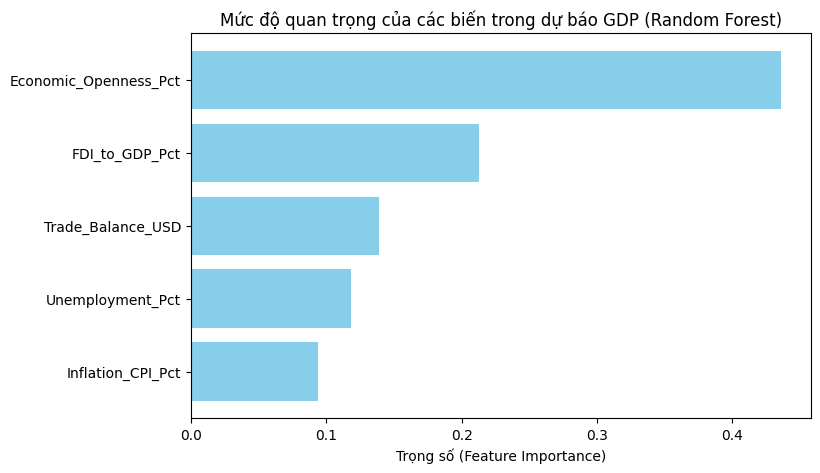

In [5]:
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

features = ['Economic_Openness_Pct', 'FDI_to_GDP_Pct', 'Trade_Balance_USD', 'Unemployment_Pct', 'Inflation_CPI_Pct']
target = 'GDP_Growth_Pct'
df_ml = df_vnm[features + [target]].dropna()

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(df_ml[features], df_ml[target])

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance['Feature'], importance['Importance'], color='skyblue')
plt.title("Mức độ quan trọng của các biến trong dự báo GDP (Random Forest)")
plt.xlabel("Trọng số (Feature Importance)")
import os
os.makedirs('fig', exist_ok=True)
plt.savefig('fig/rf_feature_importance.png')
plt.show()


## Giai đoạn 6: Khai thác Rủi ro cấu trúc & Yếu tố cân bằng vĩ mô

Phần này khai thác hai yếu tố bổ sung cực kỳ quan trọng: **Khoảng cách GDP-GNI** (thể hiện việc chảy máu lợi nhuận do làm gia công) và **Kiều hối** (tấm đệm dự trữ giúp cân bằng rủi ro tỷ giá).

### 6.1. Khoảng cách GDP và GNI (Chảy máu lợi nhuận)

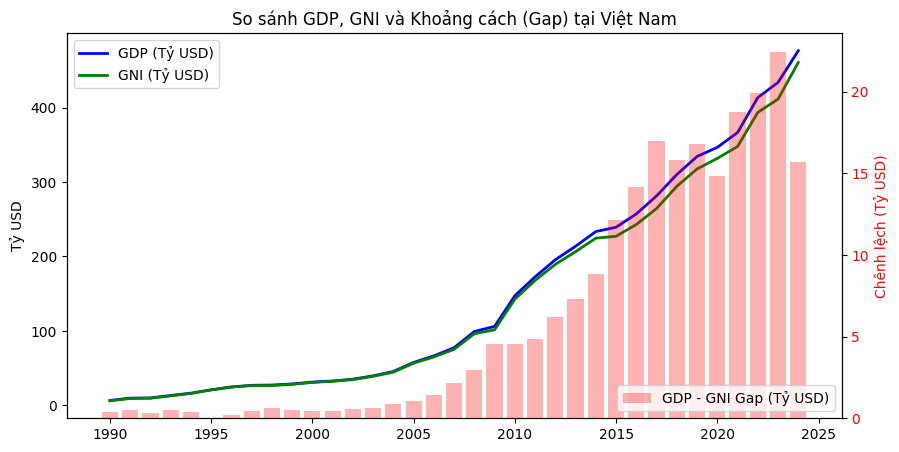

Khoảng cách GDP - GNI (Tỷ USD) trong 5 năm gần nhất:
Year
2020    14.817403
2021    18.749176
2022    19.914503
2023    22.463000
2024    15.693000
Name: GDP_GNI_Gap_Billions, dtype: float64

TỔNG chênh lệch trong 5 năm qua: 91.64 Tỷ USD


In [6]:
import matplotlib.pyplot as plt

df_vnm['GDP_GNI_Gap_Billions'] = (df_vnm['GDP_Current_USD'] - df_vnm['GNI_USD']) / 1e9

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot GDP and GNI
ax1.plot(df_vnm.index, df_vnm['GDP_Current_USD'] / 1e9, label='GDP (Tỷ USD)', color='blue', linewidth=2)
ax1.plot(df_vnm.index, df_vnm['GNI_USD'] / 1e9, label='GNI (Tỷ USD)', color='green', linewidth=2)
ax1.set_ylabel('Tỷ USD')
ax1.set_title('So sánh GDP, GNI và Khoảng cách (Gap) tại Việt Nam')
ax1.legend(loc='upper left')

# Plot the Gap on a secondary y-axis
ax2 = ax1.twinx()
ax2.bar(df_vnm.index, df_vnm['GDP_GNI_Gap_Billions'], alpha=0.3, color='red', label='GDP - GNI Gap (Tỷ USD)')
ax2.set_ylabel('Chênh lệch (Tỷ USD)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='lower right')

import os
os.makedirs('fig', exist_ok=True)
plt.savefig('fig/gdp_gni_gap.png')
plt.show()

# Thống kê lượng lợi nhuận chảy ra nước ngoài trong 5 năm gần nhất
print("Khoảng cách GDP - GNI (Tỷ USD) trong 5 năm gần nhất:")
print(df_vnm['GDP_GNI_Gap_Billions'].tail(5))
print(f"\nTỔNG chênh lệch trong 5 năm qua: {df_vnm['GDP_GNI_Gap_Billions'].tail(5).sum():.2f} Tỷ USD")


### 6.2. Kiều hối (Tấm đệm vĩ mô)

Tương quan giữa Kiều hối (% GDP) và Thâm hụt thương mại (% GDP):
                     Remittances_Pct_GDP  Trade_Deficit_Pct
Remittances_Pct_GDP             1.000000           0.224648
Trade_Deficit_Pct               0.224648           1.000000


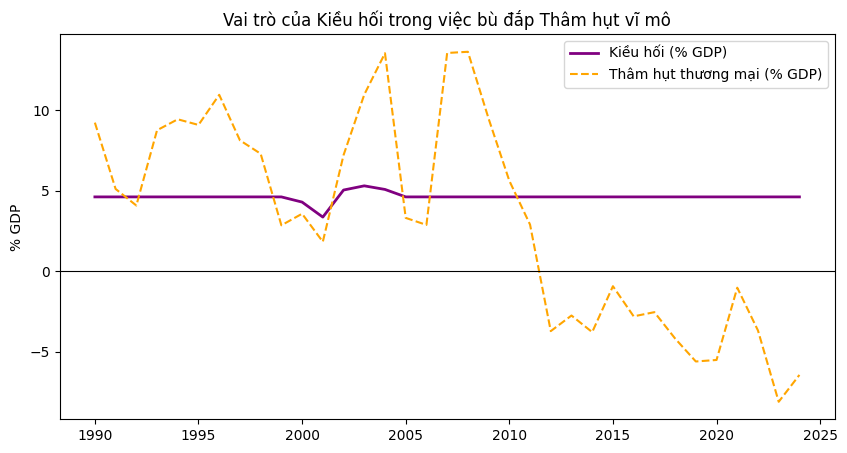

In [7]:
# Xem xét tương quan giữa Kiều hối và Thâm hụt cán cân thương mại
df_vnm['Trade_Deficit_Pct'] = - (df_vnm['Trade_Balance_USD'] / df_vnm['GDP_Current_USD'] * 100)
# Biến Trade_Deficit_Pct mang giá trị dương khi nhập siêu (thâm hụt)

print("Tương quan giữa Kiều hối (% GDP) và Thâm hụt thương mại (% GDP):")
print(df_vnm[['Remittances_Pct_GDP', 'Trade_Deficit_Pct']].corr())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_vnm.index, df_vnm['Remittances_Pct_GDP'], label='Kiều hối (% GDP)', color='purple', linewidth=2)
ax.plot(df_vnm.index, df_vnm['Trade_Deficit_Pct'], label='Thâm hụt thương mại (% GDP)', color='orange', linestyle='--')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Vai trò của Kiều hối trong việc bù đắp Thâm hụt vĩ mô')
ax.set_ylabel('% GDP')
ax.legend()
plt.savefig('fig/remittances_buffer.png')
plt.show()
